In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models

In [5]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/boston.csv")  # your file name

print(data.head())
print(data.columns)

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


In [7]:
X = data.drop('MEDV', axis=1)
y = data['MEDV']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [9]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # FIXED
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

In [10]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 600.2699 - mae: 22.6770 - val_loss: 486.1459 - val_mae: 20.5105
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 522.1714 - mae: 20.9639 - val_loss: 413.7429 - val_mae: 18.7879
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 425.8950 - mae: 18.7102 - val_loss: 304.5898 - val_mae: 15.9350
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 290.8328 - mae: 14.9965 - val_loss: 166.8843 - val_mae: 11.3313
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 154.5628 - mae: 10.1695 - val_loss: 67.7427 - val_mae: 6.7907
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 76.1023 - mae: 6.6792 - val_loss: 37.3276 - val_mae: 5.0095
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.4003 - mae: 5.2688 - val_loss: 25.3795 - val_mae: 4.1474
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34.6435 - mae: 4.4323 - val_loss: 18.8555 - val_mae: 3.5719
Epoch 9/100
23/23 ━━━━━━━━━━━

In [12]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 16.2030 - mae: 2.4133
Test Loss (MSE): 16.203001022338867
Test MAE: 2.4132988452911377


In [13]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

comparison.head()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


,Actual,Predicted
0,30.8,30.170527
1,17.1,12.797179
2,50.0,29.690992
3,20.9,20.726950
4,16.1,22.407310


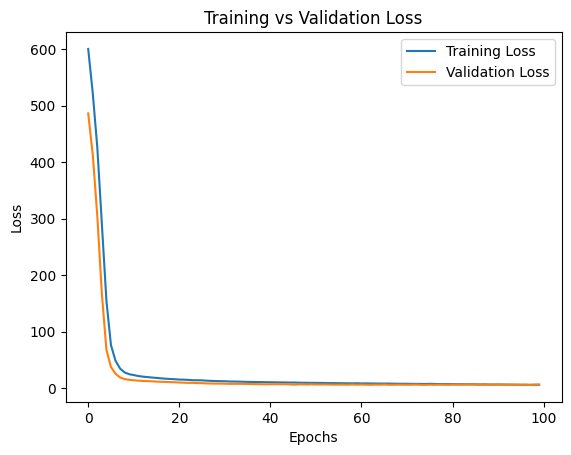

In [14]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

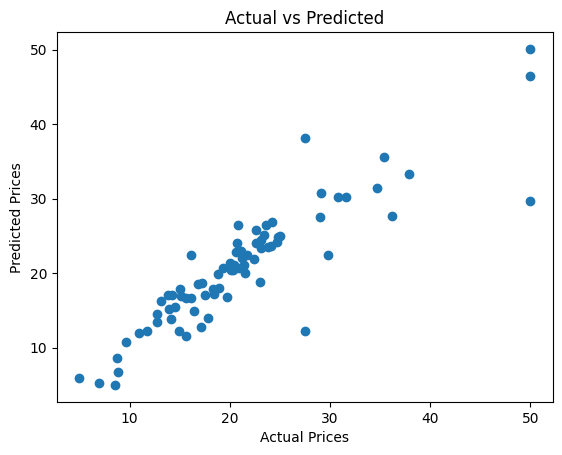

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [16]:
# Example: 13 features (must match dataset)
new_house = [[0.1, 18, 2.31, 0, 0.5, 6.5, 65, 4.5, 1, 300, 15, 390, 12]]

# Apply SAME scaling
new_house_scaled = scaler.transform(new_house)

# Predict
prediction = model.predict(new_house_scaled)

print("Predicted Price:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Price: 24.51543
